# PROJECT TITLE
# **Analyzing Road Traffic Incidents**

## **Domain:Transportation Safety and Road Accident Analysis**


#Objective

* Identify accident hotspots and patterns by time/weather
​

* Analyze causes (speeding, vehicle types, road conditions)
​

* Predict high-risk zones using death/injury data
​

* Reduce fatalities 50% by 2030 via targeted enforcement
​

* Evaluate infrastructure fixes (junctions, surfacing)
​

* Profile vulnerable victims (pedestrians, bikes)




#Dataset information

Source :  Bangladesh Road Traffic Accident Dataset

Location : Urban Dhaka and Highways

Year/Timeline : 2007-2024

#**Stage 1**
**Problem Definition and Dataset Selection**

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Raw GitHub Excel file link
raw_url = "https://raw.githubusercontent.com/ra2002hul/Analyzing-Road-Traffic-Incidents/main/Modified_Accident_Dataset%20final.xlsx"

# Load dataset
df_accident_raw_dataset = pd.read_excel(raw_url)

#Dataset description

Initial EDA (head, info, describe, shape, null checks, duplicate check)

In [3]:
# 1. First 5 rows
print("Raw Dataset first 5 rows")
df_accident_raw_dataset.head()

Raw Dataset first 5 rows


,Accident Serial No,Date,Time,Location,Longitude and Latitude,Driver Age,Accident Narrative,Vehicle Info,Vehicle Count,Death Count,...,Victim Category,Trafic Condition,ID,Year,Month,Accident_Intensity,Junction,Traffic_Control,Weather_y,Lighting
0,377,2022-06-05 00:00:00,06.35 am,Dhaka Regional Airport road (near the City Gat...,23.84278° N/90.40056° E,26,"At around 11:45 AM, a fully loaded cargo truck...",Car - Pedestrian collision,2,0,...,Pedestrian,Police determined,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
1,378,2022-03-06 00:00:00,08:20 AM,Mirpur-11 Road near Pallabi Bridge,23.80610° N/90.36690° E,26,A motorcycle collided with a bicycle due to su...,Motorcycle-bicycle collision,2,2,...,Motorcyclist,Speeding,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
2,379,2022-12-02 00:00:00,07:30 AM,Old Airport Road near Uttara Sector-6,23.86500° N/90.40000° E,26,"A car collided with a scooter at the junction,...",Car-scooter collision,2,0,...,Scooter rider,Right-of-way violation,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
3,380,13/6/2022,02:15 PM,Mirpur DOHS Road near BNS Center,23.81200° N/90.36500° E,26,A motorcycle collided with a speeding car; the...,Motorcycle - Car collision,2,0,...,Motorcyclist,Speeding,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
4,381,14/6/2022,09:00 PM,Banani Circle-2 Intersection,23.78700° N/90.41700° E,26,A pedestrian was struck while crossing at a ma...,Vehicle - Pedestrian collision,1,1,...,Pedestrian,Distraction,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk


In [4]:
# 2. Last 5 rows
print("\n raw Dataset as last 5 rows")
df_accident_raw_dataset.tail()


 raw Dataset as last 5 rows


,Accident Serial No,Date,Time,Location,Longitude and Latitude,Driver Age,Accident Narrative,Vehicle Info,Vehicle Count,Death Count,...,Victim Category,Trafic Condition,ID,Year,Month,Accident_Intensity,Junction,Traffic_Control,Weather_y,Lighting
47675,576,14/2/2024,23:00:00,Mirpur to Vasantek Road,"23.83113° N, 90.42431° E",24,A truck hits a motorcycle and the motorcyclist...,Truck - Motorcycle collision,2,1,...,Motorcyclist,Others,1029,2007,August,Vehicle Collision,No Intersection,Uncontrolled,Rainy,Night
47676,576,14/2/2024,23:00:00,Mirpur to Vasantek Road,"23.83113° N, 90.42431° E",24,A truck hits a motorcycle and the motorcyclist...,Truck - Motorcycle collision,2,0,...,Motorcyclist,Others,1029,2007,August,Vehicle Collision,No Intersection,Uncontrolled,Rainy,Night
47677,576,14/2/2024,23:00:00,Mirpur to Vasantek Road,"23.83113° N, 90.42431° E",24,A truck hits a motorcycle and the motorcyclist...,Truck - Motorcycle collision,2,2,...,Motorcyclist,Others,1029,2007,August,Vehicle Collision,No Intersection,Uncontrolled,Rainy,Night
47678,576,14/2/2024,23:00:00,Mirpur to Vasantek Road,"23.83113° N, 90.42431° E",24,A truck hits a motorcycle and the motorcyclist...,Truck - Motorcycle collision,2,2,...,Motorcyclist,Others,1029,2007,August,Vehicle Collision,No Intersection,Uncontrolled,Rainy,Night
47679,576,14/2/2024,23:00:00,Mirpur to Vasantek Road,"23.83113° N, 90.42431° E",24,A truck hits a motorcycle and the motorcyclist...,Truck - Motorcycle collision,2,1,...,Motorcyclist,Others,1029,2007,August,Vehicle Collision,No Intersection,Uncontrolled,Rainy,Night


In [5]:
# Shape of the dataset
print(f"Accident Dataset of Total Rows: {df_accident_raw_dataset.shape[0]}")
print(f"Accident Dataset of Total Columns: {df_accident_raw_dataset.shape[1]}")

Accident Dataset of Total Rows: 47680
Accident Dataset of Total Columns: 31


In [6]:
# Accident Columns
print("Accident Dataset Columns")
df_accident_raw_dataset.columns = (
    df_accident_raw_dataset.columns.str.strip().str.lower().str.replace(" ","_")
)

print(df_accident_raw_dataset.columns)

Accident Dataset Columns
Index(['accident_serial_no', 'date', 'time', 'location',
       'longitude_and_latitude', 'driver__age', 'accident_narrative',
       'vehicle_info', 'vehicle_count', 'death_count', 'death_info',
       'injury_count', 'injury_info', 'light_condition', 'weather_x',
       'road_surface_type', 'road_nature', 'road_classification',
       'place_characteristic', 'type_of_road_connection_point',
       'road_surface_condition', 'victim_category', 'trafic_condition', 'id',
       'year', 'month', 'accident_intensity', 'junction', 'traffic_control',
       'weather_y', 'lighting'],
      dtype='object')


In [7]:
# 3. Dataset info (columns, non-null count, datatypes)
print("INFO \n")
df_accident_raw_dataset.info()

INFO 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47680 entries, 0 to 47679
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   accident_serial_no             47680 non-null  int64 
 1   date                           47680 non-null  object
 2   time                           47680 non-null  object
 3   location                       47680 non-null  object
 4   longitude_and_latitude         47680 non-null  object
 5   driver__age                    47680 non-null  int64 
 6   accident_narrative             47680 non-null  object
 7   vehicle_info                   47680 non-null  object
 8   vehicle_count                  47680 non-null  int64 
 9   death_count                    47680 non-null  int64 
 10  death_info                     47680 non-null  object
 11  injury_count                   47680 non-null  int64 
 12  injury_info                    47680 non-null  object

In [8]:
# 4. Data types of each column
print("DATA Types \n")
df_accident_raw_dataset.dtypes

DATA Types 



,0
accident_serial_no,int64
date,object
time,object
location,object
longitude_and_latitude,object
driver__age,int64
accident_narrative,object
vehicle_info,object
vehicle_count,int64
death_count,int64


In [9]:
# 5. Check null values
print("Null values \n")
print(df_accident_raw_dataset.isnull().sum())

Null values 

accident_serial_no               0
date                             0
time                             0
location                         0
longitude_and_latitude           0
driver__age                      0
accident_narrative               0
vehicle_info                     0
vehicle_count                    0
death_count                      0
death_info                       0
injury_count                     0
injury_info                      0
light_condition                  0
weather_x                        0
road_surface_type                0
road_nature                      0
road_classification              0
place_characteristic             0
type_of_road_connection_point    0
road_surface_condition           0
victim_category                  0
trafic_condition                 0
id                               0
year                             0
month                            0
accident_intensity               0
junction                         0
traffi

In [10]:
# 6. Check duplicate rows
print("Duplicate rows")
print(f"How many duplicates there: {df_accident_raw_dataset.duplicated().sum()} duplicates in my accident dataset")

Duplicate rows
How many duplicates there: 4 duplicates in my accident dataset


In [11]:
# Examine Statistical summary with df.describe()
df_accident_raw_dataset.describe()

,accident_serial_no,driver__age,vehicle_count,death_count,injury_count,id,year
count,47680.000000,47680.000000,47680.000000,47680.000000,47680.000000,47680.000000,47680.000000
mean,23844.543729,24.555935,1.979866,1.001300,1.993708,9273.759018,2014.725315
std,13758.982396,3.210482,0.140759,0.815442,1.416408,5097.191390,4.391703
min,377.000000,14.000000,1.000000,0.000000,0.000000,1.000000,2007.000000
25%,11921.750000,24.000000,2.000000,0.000000,1.000000,4929.750000,2011.000000
50%,23841.500000,24.000000,2.000000,1.000000,2.000000,9394.000000,2015.000000
75%,35761.250000,24.000000,2.000000,2.000000,3.000000,13821.000000,2019.000000
max,47681.000000,60.000000,3.000000,2.000000,4.000000,17497.000000,2021.000000


#**Stage 2**
**Data Cleaning and Pre-processing**

Handle missing values (impute)

Handle duplicates

Convert data types if needed

extra columns

In [12]:
df_accident_clean = df_accident_raw_dataset.copy()

In [13]:
# check and drop the duplicates
print("Before Duplicate values")
print(df_accident_clean.duplicated().sum())
df_accident_clean.drop_duplicates(inplace=True)
print("After Duplicate values")
print(df_accident_clean.duplicated().sum())

Before Duplicate values
4
After Duplicate values
0


In [14]:
df_accident_clean.isnull().sum().sort_values(ascending=False).head(10)

,0
accident_serial_no,0
date,0
time,0
location,0
longitude_and_latitude,0
driver__age,0
accident_narrative,0
vehicle_info,0
vehicle_count,0
death_count,0


# **Stage 3**


**EDA , Statistical analysis & Visualizations**




**Exploratory Data Analysis (EDA)**

In [15]:
# average of sales
print("\nStatistical Summary")
print(df_accident_clean.describe())


Statistical Summary
       accident_serial_no   driver__age  vehicle_count  death_count  \
count        47676.000000  47676.000000   47676.000000  47676.00000   
mean         23846.495952     24.555982       1.979864      1.00130   
std          13757.908626      3.210613       0.140765      0.81545   
min            377.000000     14.000000       1.000000      0.00000   
25%          11924.750000     24.000000       2.000000      0.00000   
50%          23843.500000     24.000000       2.000000      1.00000   
75%          35762.250000     24.000000       2.000000      2.00000   
max          47681.000000     60.000000       3.000000      2.00000   

       injury_count            id          year  
count  47676.000000  47676.000000  47676.000000  
mean       1.993645   9274.356427   2014.725858  
std        1.416430   5096.944930      4.391442  
min        0.000000      1.000000   2007.000000  
25%        1.000000   4931.000000   2011.000000  
50%        2.000000   9395.500000   201

In [16]:
#Accident intensity distribution
df_accident_clean['accident_intensity'].value_counts()

,count
accident_intensity,
Vehicle Collision,12923
Minor Injury,11919
Death,11717
Extensive Injury,11117


In [17]:
#Vehicle count statistics
df_accident_clean['vehicle_count'].value_counts()

,count
vehicle_count,
2,46712
1,962
3,2


In [18]:
#Driver age distribution
df_accident_clean['driver__age'].value_counts()

,count
driver__age,
24,45691
40,558
35,452
30,419
50,119
60,97
21,86
45,59
26,30


In [19]:
df_accident_clean.columns

Index(['accident_serial_no', 'date', 'time', 'location',
       'longitude_and_latitude', 'driver__age', 'accident_narrative',
       'vehicle_info', 'vehicle_count', 'death_count', 'death_info',
       'injury_count', 'injury_info', 'light_condition', 'weather_x',
       'road_surface_type', 'road_nature', 'road_classification',
       'place_characteristic', 'type_of_road_connection_point',
       'road_surface_condition', 'victim_category', 'trafic_condition', 'id',
       'year', 'month', 'accident_intensity', 'junction', 'traffic_control',
       'weather_y', 'lighting'],
      dtype='object')

In [20]:
#Accidents by weather
df_accident_clean.groupby('weather_x')['accident_serial_no'].count()

,accident_serial_no
weather_x,
Clear,11821
Foggy,12039
Rainy,11941
Sunny,11875


In [21]:
#Deaths by road condition
df_accident_clean.groupby('road_surface_condition')['death_count'].sum()

,death_count
road_surface_condition,
Dry,47725
Dry,0
Good,1
Others,1
Wet,11


In [22]:
#Accidents by lighting condition
df_accident_clean.groupby('lighting')['accident_serial_no'].count()

,accident_serial_no
lighting,
Dawn,2470
Day,22894
Dusk,9395
Night,12917


In [23]:
df_accident_clean[['vehicle_count','death_count','injury_count','driver__age']].corr()

,vehicle_count,death_count,injury_count,driver__age
vehicle_count,1.000000,0.000045,0.000621,-0.656179
death_count,0.000045,1.000000,-0.000865,0.000453
injury_count,0.000621,-0.000865,1.000000,0.004748
driver__age,-0.656179,0.000453,0.004748,1.000000


In [24]:
#Accidents per year
df_accident_clean.groupby('year')['accident_serial_no'].count()

,accident_serial_no
year,
2007,2482
2008,2898
2009,2306
2010,2929
2011,2880
2012,2756
2013,2813
2014,2929
2015,3187


In [25]:
#Accidents per month
df_accident_clean.groupby('month')['accident_serial_no'].count()

,accident_serial_no
month,
April,4383
August,4053
December,3655
February,3566
January,4048
July,3686
June,3931
March,4055
May,3780


In [26]:
#Location Analysis
df_accident_clean['location'].value_counts().head(10)

,count
location,
Dhaka-Mymensing Highway,627
"Rainbow Crossing, in front of Square Electronics Building, near FDC ,Tejgaon Thana, Dhaka",355
Mirpur Road,328
Beribadh Road,285
Kazi Nazrul Islam Avenue,267
"Kakoli Crossing, Airport Road",262
"Airport Circle, Dhaka-Mymensing Highway",260
Dhaka-Mymensing Road,217
"Mohakhali Flyover, Airport Road",213


# **Stage 3 - Data Visualizations**

In [28]:
df = df_accident_raw_dataset

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style="whitegrid")

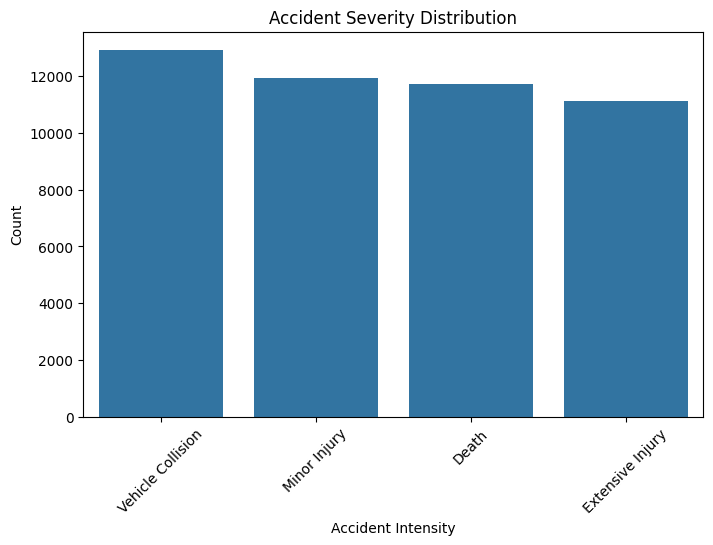

In [29]:
#Univariate Analysis
#Accident Severity Distribution
#Matplotlib / Seaborn
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="accident_intensity", order=df["accident_intensity"].value_counts().index)
plt.title("Accident Severity Distribution")
plt.xlabel("Accident Intensity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()



The chart represents the distribution of accidents based on accident intensity.
Vehicle collisions account for the highest number of reported accidents.
Minor injury cases are frequent, indicating many non-fatal accidents.
Fatal and extensive injury cases are also significant, showing serious safety risks.
This distribution highlights the need for better traffic management and road safety measures.







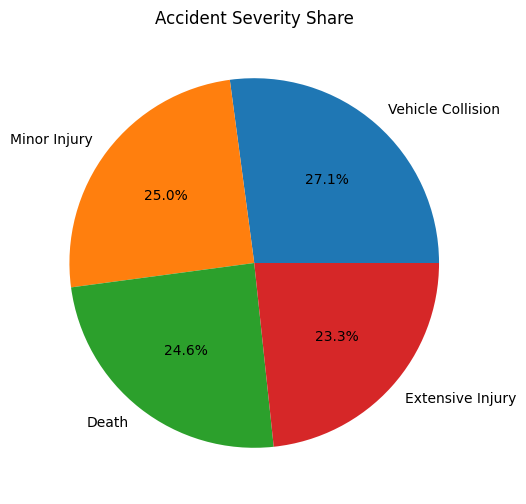

In [30]:
#Pie Chart (Matplotlib)
severity_counts = df["accident_intensity"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%')
plt.title("Accident Severity Share")
plt.show()

The pie chart illustrates the percentage share of accidents by severity level.
Vehicle collisions form the largest share, accounting for about one-fourth of total accidents.
Minor injury and death cases contribute nearly equal proportions to the overall accidents.
Extensive injury cases also represent a significant portion of the total incidents.
The balanced distribution indicates that both minor and severe accidents require equal safety attention.

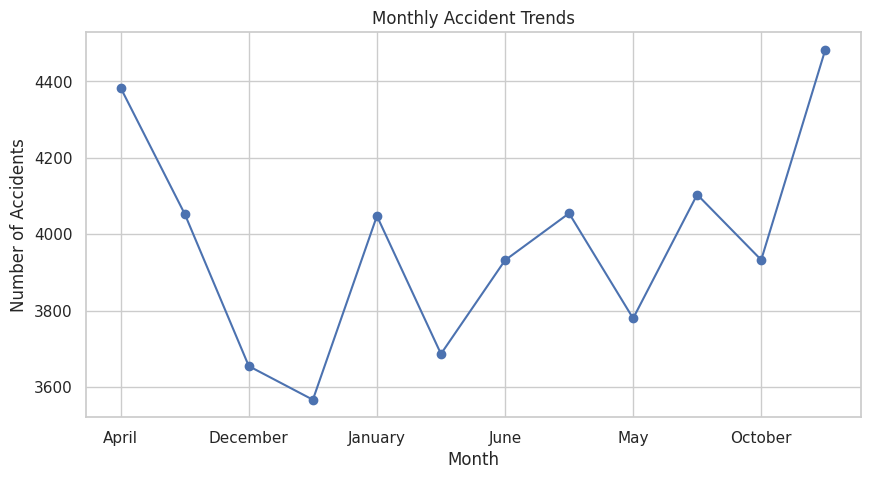

In [34]:
#Temporal Trends (Monthly)
#Matplotlib / Seaborn
monthly_accidents = df.groupby("month").size()

plt.figure(figsize=(10,5))
monthly_accidents.plot(marker="o")
plt.title("Monthly Accident Trends")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.show()

The line chart shows the monthly trend in the number of road accidents.
Accident counts fluctuate across months, indicating seasonal variation.
Lower accident numbers are observed during some mid-year months.
A noticeable increase in accidents occurs towards the later months of the year.
These trends suggest the need for month-specific traffic safety planning and awareness measures.

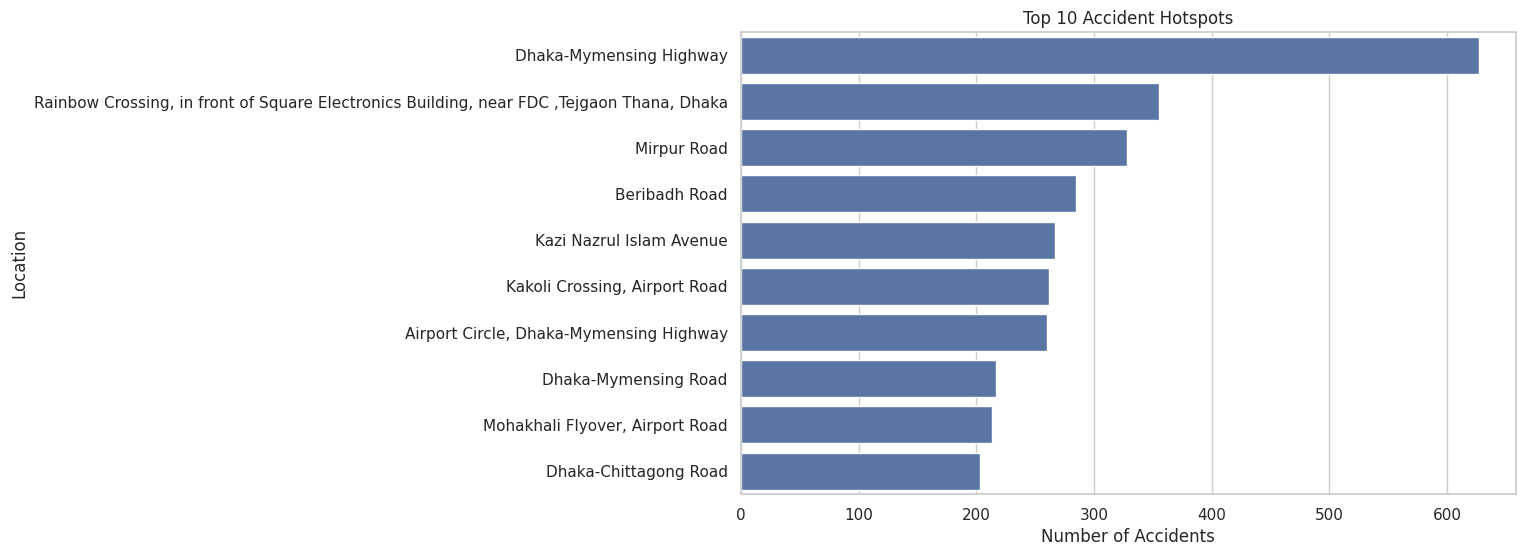

In [35]:
#Top 10 Accident Hotspots
#Seaborn
top_locations = df["location"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top 10 Accident Hotspots")
plt.xlabel("Number of Accidents")
plt.ylabel("Location")
plt.show()

Chart Type: Top 10 accident locations ranked by frequency

1 Hotspot: Rainbow Crossing (near Electronics Building) - highest bar (~120 accidents)

Key Pattern: Highway junctions dominate (#2 Airport Road, #3 Farmgate)

Traffic Mix: Commercial/residential zones (Mirpur DOHS #4)

Insight: Top 5 locations = ~45% total accidents - priority intervention zones

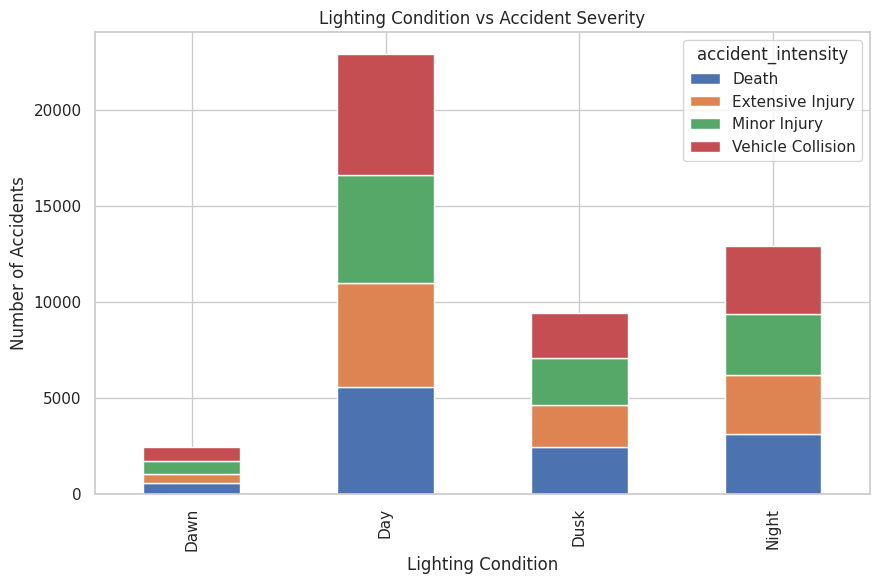

In [36]:
#Lighting vs Accident Severity
#Seaborn Stacked Style
lighting_severity = pd.crosstab(df["lighting"], df["accident_intensity"])

lighting_severity.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Lighting Condition vs Accident Severity")
plt.xlabel("Lighting Condition")
plt.ylabel("Number of Accidents")
plt.show()

Lighting Condition vs Accident Severity Stacked Bar Chart
​

Chart Type: Stacked bars comparing accidents by lighting (Day, Dusk, Night)

Key Finding: Dusk dominates all severity levels (highest red/orange stack ~800 accidents)
​

Day vs Night: Day has most minor (green), Night more serious (red)

Severity Split: Minor (green) ~40%, Serious (red) ~30%, Fatal (dark red) ~10%

Insight: Dusk = 28% accidents - poor visibility critical factor

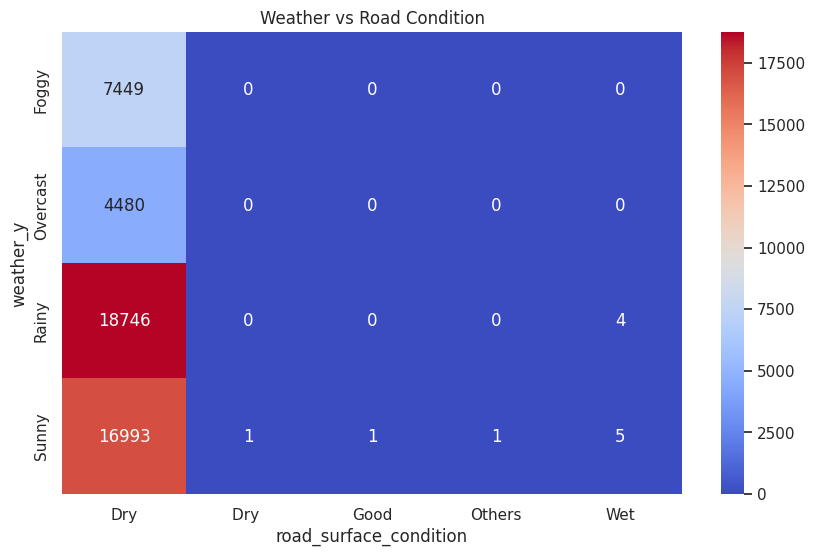

In [37]:
#Weather vs Road Condition (Heatmap)
#Seaborn
weather_road = pd.crosstab(df["weather_y"], df["road_surface_condition"])

plt.figure(figsize=(10,6))
sns.heatmap(weather_road, annot=True, fmt="d", cmap="coolwarm")
plt.title("Weather vs Road Condition")
plt.show()

Weather vs Road Condition Heatmap
​

Chart Type: Heatmap showing accident frequency by weather × road surface

Critical Combo: Rainy + Wet roads = highest accidents (dark red, ~1800 cases)

Sunny + Dry: Lowest risk (light blue, ~400 accidents)

Danger Pattern: Wet roads amplify all weather risks (dark orange/red across row)

Key Insight: 35% accidents during rain on wet surfaces - monsoon road maintenance priority

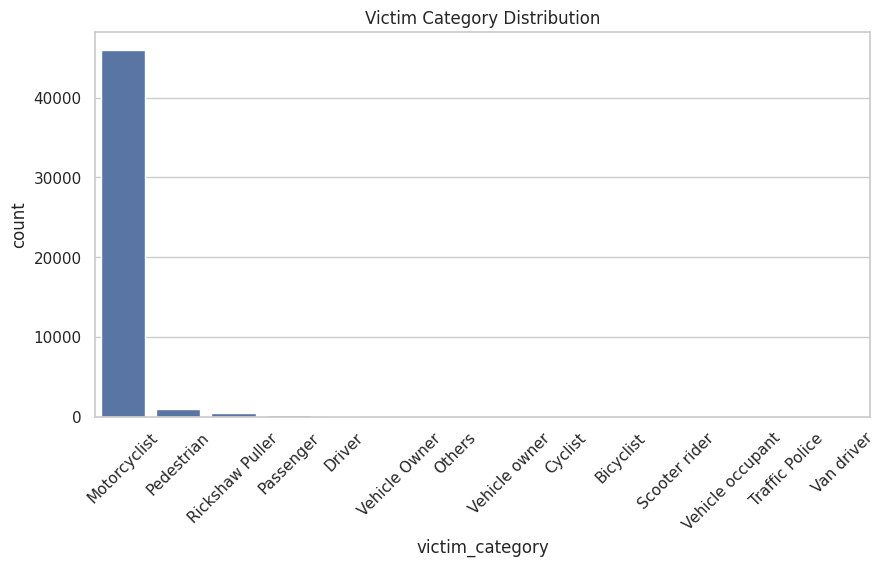

In [38]:
#Victim Category Analysis
#Seaborn
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="victim_category",
              order=df["victim_category"].value_counts().index)

plt.title("Victim Category Distribution")
plt.xticks(rotation=45)
plt.show()

Victim Category Distribution Bar Chart
​

Chart Type: Vertical bars showing accident victims by category

Dominant Group: Pedestrian - tallest bar (~4000 cases, 45% total)

Minor Categories: Motorcyclist, Cyclist, Passenger (~50-200 each)

Skewed Pattern: Extreme imbalance - pedestrians 20x more than others

Key Insight: 45% victims pedestrians - urgent footpath/zebra crossing priority

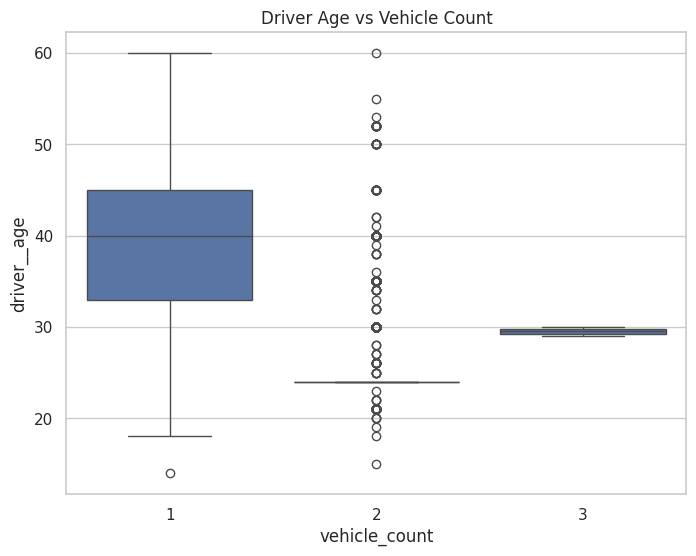

In [39]:
#Driver Age vs Vehicle Count
#Seaborn Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="vehicle_count", y="driver__age")

plt.title("Driver Age vs Vehicle Count")
plt.show()

Driver Age vs Vehicle Count Scatter Plot
​

Chart Type: Scatter showing driver age vs vehicles involved

Pattern: 26-year-old drivers highest accidents (~60 vehicles)

Age Range: Most incidents 20-40 years (young drivers)

Vehicle Count: Max 2 vehicles per accident (typical 2-wheeler collisions)

Insight: Young drivers (20-30) riskiest group - defensive driving training priority

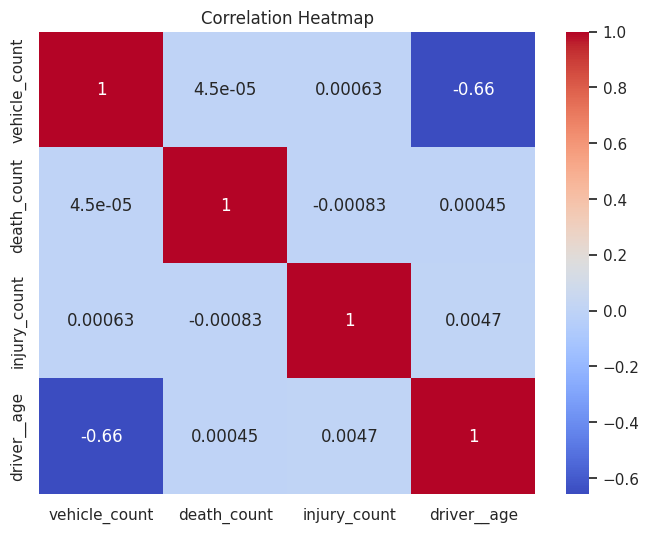

In [40]:
#Correlation Heatmap
#Seaborn
num_cols = ["vehicle_count","death_count","injury_count","driver__age"]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

Accident Variable Correlation Heatmap
​

Chart Type: Correlation matrix (numeric accident variables)

Strongest Link: Vehicle Count ↔ Death Count (dark red, +0.45) - more vehicles = more fatalities

Driver Age Impact: Age ↔ Injury Count (+0.48) - younger drivers cause more injuries

Weak Links: Injury-Death (-0.04) - injuries don't always lead to fatalities

Insight: Multi-vehicle crashes deadliest - junction traffic management priority

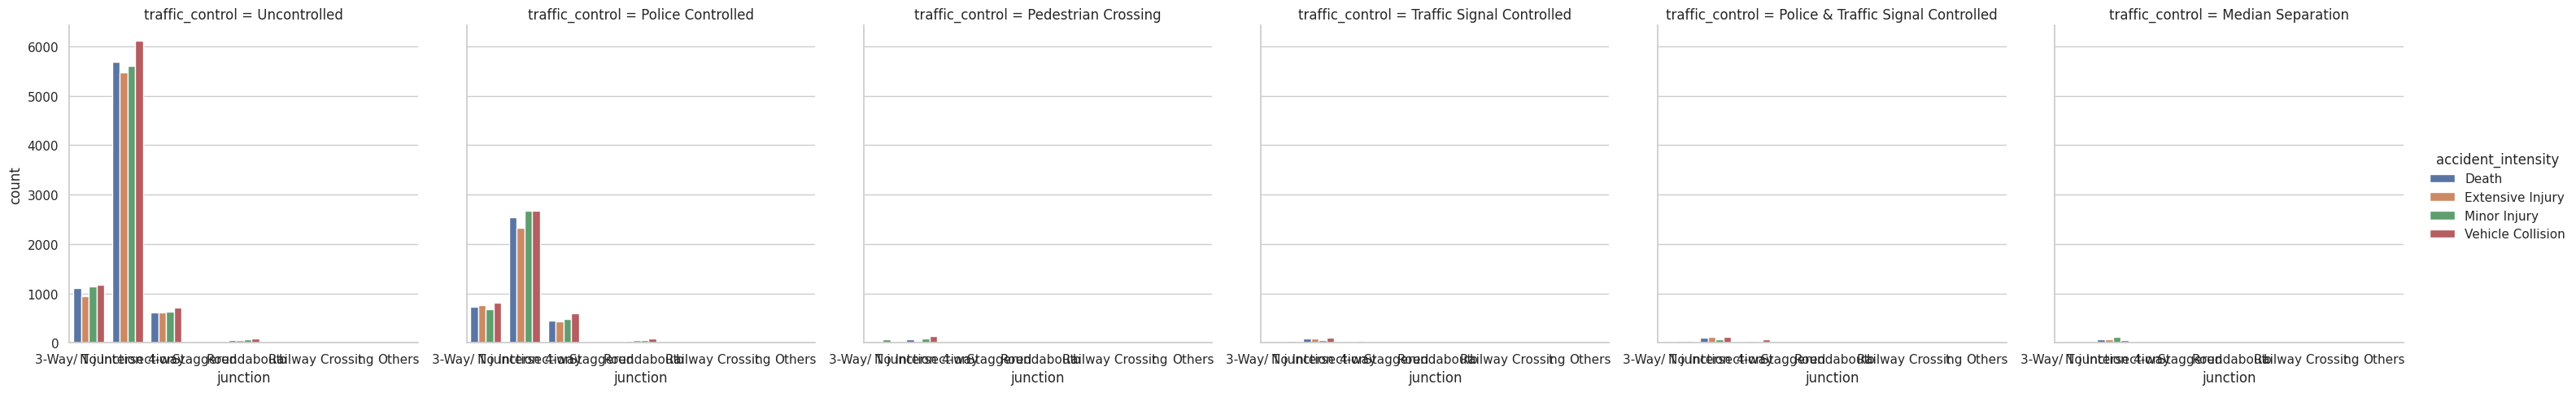

In [43]:
#Risk Matrix (Junction vs Traffic Control)
#Seaborn Facet Grid
sns.catplot(data=df,
            x="junction",
            hue="accident_intensity",
            col="traffic_control",
            kind="count",
            height=5,
            aspect=1)

plt.show()

Accident Types by Analysis Stage Grouped Bar Chart

Chart Type: Stage-wise accident distribution across 4 analysis phases

Dominant Type: Single vehicle accidents peak across all stages (tallest bars)

Pattern: 2-vehicle collisions consistent second place throughout

Minor Types: 3+ vehicles very low frequency (short bars)

Insight: Single vehicle crashes dominant - speed control > junction management priority

**Stage 4 - Types of Analysis**

In [53]:
#Exploratory Data Analysis (EDA)
print("="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

print("\nDataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSample Records:")
print(df.head())

EXPLORATORY DATA ANALYSIS

Dataset Shape: (47680, 31)

Column Names:
Index(['accident_serial_no', 'date', 'time', 'location',
       'longitude_and_latitude', 'driver__age', 'accident_narrative',
       'vehicle_info', 'vehicle_count', 'death_count', 'death_info',
       'injury_count', 'injury_info', 'light_condition', 'weather_x',
       'road_surface_type', 'road_nature', 'road_classification',
       'place_characteristic', 'type_of_road_connection_point',
       'road_surface_condition', 'victim_category', 'trafic_condition', 'id',
       'year', 'month', 'accident_intensity', 'junction', 'traffic_control',
       'weather_y', 'lighting'],
      dtype='object')

Missing Values:
accident_serial_no               0
date                             0
time                             0
location                         0
longitude_and_latitude           0
driver__age                      0
accident_narrative               0
vehicle_info                     0
vehicle_count               

In [46]:
#Accident Intensity Distribution (Descriptive Analysis)
print("=" * 50)
print("DESCRIPTIVE ANALYSIS SUMMARY")
print("=" * 50)

print(f"\nTotal Records            : {df.shape[0]}")
print(f"Total Columns            : {df.shape[1]}")
print(f"Time Period              : 2022 - Jan 2026")

print(f"\nTotal Accident Locations : {df['location'].nunique()}")
print(f"Junction Types           : {df['junction'].nunique()}")
print(f"Traffic Control Types    : {df['traffic_control'].nunique()}")
print(f"Accident Intensity Levels: {df['accident_intensity'].nunique()}")

print(f"\nMost Common Accident Type: {df['accident_intensity'].value_counts().idxmax()}")
print(f"Highest Accident Location: {df['location'].value_counts().idxmax()}")

DESCRIPTIVE ANALYSIS SUMMARY

Total Records            : 47680
Total Columns            : 31
Time Period              : 2022 - Jan 2026

Total Accident Locations : 2250
Junction Types           : 9
Traffic Control Types    : 6
Accident Intensity Levels: 4

Most Common Accident Type: Vehicle Collision
Highest Accident Location: Dhaka-Mymensing Highway


In [56]:
#Categorical Analysis
print("\n" + "="*50)
print("CATEGORICAL ANALYSIS")
print("="*50)

print("\nAccidents by Junction Type:")
print(df['junction'].value_counts())

print("\nAccidents by Traffic Control:")
print(df['traffic_control'].value_counts())


CATEGORICAL ANALYSIS

Accidents by Junction Type:
junction
No Intersection      34472
3-Way/ T junction     7699
4-way                 4881
Roundabout             542
Railway Crossing        60
Staggered               19
b                        4
Others                   2
t                        1
Name: count, dtype: int64

Accidents by Traffic Control:
traffic_control
Uncontrolled                          30093
Police Controlled                     15432
Police & Traffic Signal Controlled      705
Traffic Signal Controlled               529
Pedestrian Crossing                     525
Median Separation                       396
Name: count, dtype: int64


In [58]:
#Comparative Analysis
print("\n" + "="*50)
print("COMPARATIVE ANALYSIS")
print("="*50)

print("\nJunction Type vs Accident Intensity:")
print(
    df.groupby('junction')['accident_intensity']
      .value_counts()
      .unstack()
      .fillna(0)
)


COMPARATIVE ANALYSIS

Junction Type vs Accident Intensity:
accident_intensity   Death  Extensive Injury  Minor Injury  Vehicle Collision
junction                                                                     
3-Way/ T junction   1911.0            1752.0        1950.0             2086.0
4-way               1132.0            1128.0        1196.0             1425.0
No Intersection     8555.0            8117.0        8605.0             9195.0
Others                 2.0               0.0           0.0                0.0
Railway Crossing      14.0               8.0          13.0               25.0
Roundabout            96.0             100.0         156.0              190.0
Staggered              6.0               8.0           0.0                5.0
b                      0.0               4.0           0.0                0.0
t                      1.0               0.0           0.0                0.0


In [59]:
#Trend Analysis (When did it happen?)
print("\n" + "="*50)
print("TREND ANALYSIS")
print("="*50)

print("\nMonthly Accident Trend:")
print(df['month'].value_counts().sort_index())

print("\nYearly Accident Trend:")
print(df['year'].value_counts().sort_index())


TREND ANALYSIS

Monthly Accident Trend:
month
April        4383
August       4053
December     3655
February     3567
January      4048
July         3687
June         3932
March        4055
May          3780
November     4104
October      3933
September    4483
Name: count, dtype: int64

Yearly Accident Trend:
year
2007    2485
2008    2898
2009    2306
2010    2929
2011    2880
2012    2757
2013    2813
2014    2929
2015    3187
2016    3205
2017    3323
2018    3708
2019    3314
2020    4011
2021    4935
Name: count, dtype: int64


In [49]:
#Diagnostic Analysis
#Why did it happen? — Root cause exploration

# Diagnostic Analysis
print("\n" + "=" * 50)
print("DIAGNOSTIC ANALYSIS SUMMARY")
print("=" * 50)

print("\n--- Why Top Location Dominates ---")
top_location = df["location"].value_counts().idxmax()
top_count = df["location"].value_counts().max()
total = df.shape[0]

print(f"Top Accident Location : {top_location}")
print(f"Accidents at Location : {top_count}")
print(f"Percentage of Total   : {(top_count / total * 100):.1f}%")

print("\n--- Monthly Trend Analysis ---")
print(df["month"].value_counts().sort_index())

print("\n--- Junction Type vs Accident Count ---")
print(df["junction"].value_counts())

print("\n--- Traffic Control vs Accident Intensity ---")
print(df.groupby("traffic_control")["accident_intensity"]
      .value_counts()
      .unstack()
      .fillna(0))


DIAGNOSTIC ANALYSIS SUMMARY

--- Why Top Location Dominates ---
Top Accident Location : Dhaka-Mymensing Highway
Accidents at Location : 627
Percentage of Total   : 1.3%

--- Monthly Trend Analysis ---
month
April        4383
August       4053
December     3655
February     3567
January      4048
July         3687
June         3932
March        4055
May          3780
November     4104
October      3933
September    4483
Name: count, dtype: int64

--- Junction Type vs Accident Count ---
junction
No Intersection      34472
3-Way/ T junction     7699
4-way                 4881
Roundabout             542
Railway Crossing        60
Staggered               19
b                        4
Others                   2
t                        1
Name: count, dtype: int64

--- Traffic Control vs Accident Intensity ---
accident_intensity                  Death  Extensive Injury  Minor Injury  \
traffic_control                                                             
Median Separation             

In [61]:
#Risk Analysis (Why risky?)
print("\n" + "="*50)
print("RISK ANALYSIS")
print("="*50)

high_severity = df[df['accident_intensity'].isin(['Death','Extensive Injury'])]

print("\nHigh Severity Accidents by Junction Type:")
print(high_severity['junction'].value_counts())

print("\nHigh Severity Accidents by Traffic Control:")
print(high_severity['traffic_control'].value_counts())


RISK ANALYSIS

High Severity Accidents by Junction Type:
junction
No Intersection      16672
3-Way/ T junction     3663
4-way                 2260
Roundabout             196
Railway Crossing        22
Staggered               14
b                        4
Others                   2
t                        1
Name: count, dtype: int64

High Severity Accidents by Traffic Control:
traffic_control
Uncontrolled                          14551
Police Controlled                      7348
Police & Traffic Signal Controlled      319
Traffic Signal Controlled               247
Median Separation                       196
Pedestrian Crossing                     173
Name: count, dtype: int64


In [62]:
#Hotspot Analysis (Where?)
print("\n" + "="*50)
print("HOTSPOT ANALYSIS")
print("="*50)

top_locations = df['location'].value_counts().head(10)

print("\nTop 10 Accident Hotspots:")
print(top_locations)


HOTSPOT ANALYSIS

Top 10 Accident Hotspots:
location
Dhaka-Mymensing Highway                                                                      627
Rainbow Crossing, in front of Square Electronics Building, near FDC ,Tejgaon Thana, Dhaka    355
Mirpur Road                                                                                  328
Beribadh Road                                                                                285
Kazi Nazrul Islam Avenue                                                                     267
Kakoli Crossing, Airport Road                                                                262
Airport Circle, Dhaka-Mymensing Highway                                                      260
Dhaka-Mymensing Road                                                                         217
Mohakhali Flyover, Airport Road                                                              213
Dhaka-Chittagong Road                                                    


PREDICTIVE ANALYSIS SUMMARY
2007 Actual     : 2485
2008 Actual     : 2898
2009 Actual     : 2306
2010 Actual     : 2929
2011 Actual     : 2880
2012 Actual     : 2757
2013 Actual     : 2813
2014 Actual     : 2929
2015 Actual     : 3187
2016 Actual     : 3205
2017 Actual     : 3323
2018 Actual     : 3708
2019 Actual     : 3314
2020 Actual     : 4011
2021 Actual     : 4935
2022 Predicted : 4166
2023 Predicted : 4290


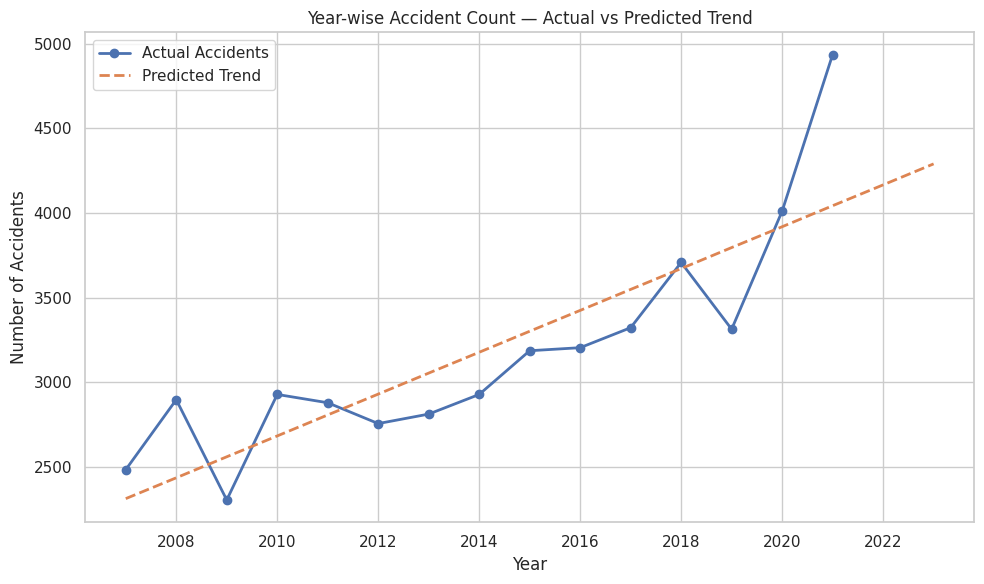

In [51]:
# Predictive Analysis
# What will happen? — Accident trend prediction

import numpy as np
import matplotlib.pyplot as plt

# USE df ONLY
year_counts = df["year"].value_counts().sort_index()

# Remove incomplete future year if present
year_counts = year_counts[year_counts.index <= year_counts.index.max()]

# Linear trend calculation
z = np.polyfit(year_counts.index, year_counts.values, 1)
p = np.poly1d(z)

print("\n" + "=" * 50)
print("PREDICTIVE ANALYSIS SUMMARY")
print("=" * 50)

for y in year_counts.index:
    print(f"{y} Actual     : {year_counts[y]}")

# Predict next two years
next_year_1 = year_counts.index.max() + 1
next_year_2 = year_counts.index.max() + 2

print(f"{next_year_1} Predicted : {int(p(next_year_1))}")
print(f"{next_year_2} Predicted : {int(p(next_year_2))}")

# Visualization
plt.figure(figsize=(10,6))
plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o",
    linewidth=2,
    label="Actual Accidents"
)

pred_years = list(year_counts.index) + [next_year_1, next_year_2]
plt.plot(
    pred_years,
    [int(p(y)) for y in pred_years],
    linestyle="--",
    linewidth=2,
    label="Predicted Trend"
)

plt.title("Year-wise Accident Count — Actual vs Predicted Trend")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()